# Segmentación del Conjunto de Datos

En esta sección, exploraremos las técnicas fundamentales para fraccionar nuestra base de información en subconjuntos de entrenamiento, validación y evaluación final.

Continuaremos trabajando con el dataset **NSL-KDD**, el cual es una evolución del clásico KDD’99. Este recurso es esencial para poner a prueba sistemas encargados de detectar intrusiones en redes informáticas. Los registros aquí presentes clasifican las conexiones entre tráfico legítimo y diversos vectores de ataque.

A pesar de que las redes han evolucionado, NSL-KDD permanece como un estándar académico gracias a su organización y a que evita problemas de sesgo presentes en versiones anteriores.

### Origen de la información
Los datos utilizados se pueden obtener en el siguiente repositorio de Kaggle: **https://www.kaggle.com/datasets/hassan06/nslkdd**.

### 0. Configuración Inicial
Importamos las librerías necesarias para la manipulación de datos y la visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

### 1. Carga del Dataset
Procedemos a leer el archivo CSV y visualizamos las primeras filas para confirmar que la estructura es correcta.

In [2]:
df = pd.read_csv('KDDTrain+.csv')
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### 2. División Manual de Datos
Una forma directa de separar los datos es mediante el uso de índices o funciones de muestreo aleatorio. Aquí dividiremos el total en dos bloques principales: entrenamiento y prueba.

In [3]:
# Establecemos una semilla para que los resultados sean reproducibles
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Definimos el punto de corte (80% para entrenamiento)
split_index = int(len(df_shuffled) * 0.8)

train_set = df_shuffled.iloc[:split_index]
test_set = df_shuffled.iloc[split_index:]

print(f"Registros de entrenamiento: {len(train_set)}")
print(f"Registros de prueba: {len(test_set)}")

Registros de entrenamiento: 100778
Registros de prueba: 25195


### 3. Segmentación con Scikit-Learn
Para mayor eficiencia, utilizaremos la función `train_test_split`. Esta herramienta permite realizar particiones estratificadas, lo cual asegura que la proporción de las clases (normal vs ataque) se mantenga similar en ambos conjuntos.

In [4]:
X = df.drop('class', axis=1)
y = df['class']

# Realizamos la división en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (100778, 42)
Dimensiones de X_test: (25195, 42)


### 4. Creación de un Conjunto de Validación
A menudo es necesario un tercer subconjunto para ajustar los parámetros del modelo sin contaminar el conjunto de prueba final. Aplicaremos una segunda división sobre los datos de entrenamiento para obtener este bloque de validación.

In [5]:
# Del 80% inicial, reservamos una parte para validación
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(f"Datos finales de entrenamiento: {len(X_train_final)}")
print(f"Datos de validación: {len(X_val)}")
print(f"Datos de prueba: {len(X_test)}")

Datos finales de entrenamiento: 75583
Datos de validación: 25195
Datos de prueba: 25195


### 5. Comparativa Visual de la Distribución
Es vital confirmar que la distribución de la variable objetivo sea consistente tras la fragmentación.

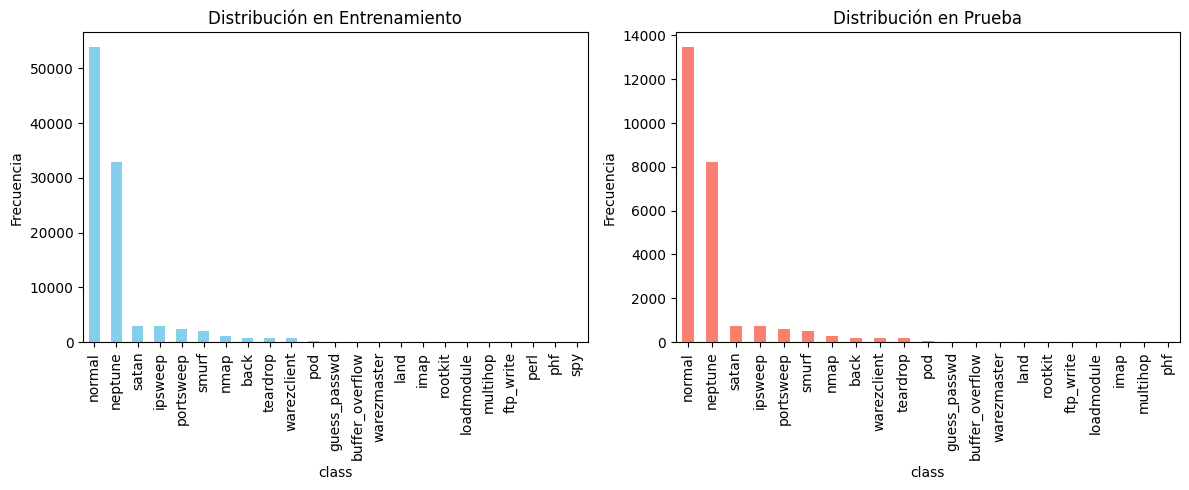

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Distribución en Entrenamiento')
ax[0].set_ylabel('Frecuencia')

y_test.value_counts().plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Distribución en Prueba')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()